# Transformer (base) — WMT14 EN→DE, JAX/Flax

Faithful implementation of *Attention Is All You Need* (Vaswani et al., 2017).
Preprocessing, shared-BPE tokenisation, length-bucketed token batching, the Noam
LR schedule, label-smoothed loss, gradient accumulation, checkpointing
(safetensors), greedy + beam-search decoding, checkpoint averaging, and BLEU —
all in a single self-contained notebook.

**Key design choices**
- **LayerNorm, not BatchNorm** → `TrainState` carries no `batch_stats`; nothing mutable in `apply`.
- **Step-based, not epoch-based** → the paper trains for a fixed number of optimiser steps (base = 100k).
- **BLEU + sample translations**, not accuracy / confusion matrix / image grids.
- **Plain Adam (β=0.9, 0.98, ε=1e-9) + Noam schedule**, not AdamW + cosine.
- **Token-budget bucketed batching** (≈25k tokens/batch), not fixed image batches.

**Colab Pro reality check.** The paper's base model is 100k steps at ~25k
tokens/batch (12 h on 8×P100). That will not finish in one Pro session on a
single GPU. Use `PRESET = "colab"`: same architecture and effective batch
(via gradient accumulation), smaller vocab / max-len / step budget so it
actually trains and checkpoints within a session. `PRESET = "paper"` keeps the
exact paper hyper-parameters for when you have the compute.

## 1 · Install & verify JAX

In [1]:
!pip install -q flax optax tensorflow-datasets safetensors sentencepiece sacrebleu
import jax
print("JAX version :", jax.__version__)
print("Devices     :", jax.devices())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.4 MB/s eta 0:00:00
JAX version : 0.7.2
Devices     : [CudaDevice(id=0)]


## 2 · Imports

In [2]:
import os, json, time, math, glob, hashlib, datetime
from functools import partial
from typing import Any

import numpy as np
import jax.numpy as jnp
import flax.linen as nn
import optax
from flax.training import train_state

import tensorflow as tf
import tensorflow_datasets as tfds
tf.config.set_visible_devices([], "GPU")   # keep the GPU for JAX, not tf.data

import sentencepiece as spm
import sacrebleu
import matplotlib.pyplot as plt

key = jax.random.PRNGKey(0)

## 3 · Mount Google Drive & dataset cache

In [3]:
from google.colab import drive
drive.mount("/content/drive")
DRIVE_DATASETS_ROOT    = "/content/drive/MyDrive/colab_datasets"
DRIVE_CHECKPOINTS_ROOT = "/content/drive/MyDrive/colab_checkpoints"
os.makedirs(DRIVE_DATASETS_ROOT, exist_ok=True)
os.makedirs(DRIVE_CHECKPOINTS_ROOT, exist_ok=True)
print(f"Dataset cache root    : {DRIVE_DATASETS_ROOT}")
print(f"Checkpoint root       : {DRIVE_CHECKPOINTS_ROOT}")

Mounted at /content/drive
Dataset cache root    : /content/drive/MyDrive/colab_datasets
Checkpoint root       : /content/drive/MyDrive/colab_checkpoints


## 4 · Data — WMT14 EN→DE

The paper: WMT 2014 English→German (~4.5M sentence pairs), a **shared** source-
target byte-pair vocabulary of ~37k, batches built to hold **≈25 000 source and
25 000 target tokens** (length-bucketed). Dev = `newstest2013`, test =
`newstest2014`. We reproduce all of that here; the `colab` preset only shrinks
the knobs, never the pipeline.

In [4]:
# ── Config ──────────────────────────────────────────────────────────────
NOTEBOOK_TITLE = "Transformer (base) — WMT14 EN->DE (JAX/Flax)"
DATASET_SLUG   = "wmt14_ende"
TFDS_NAME      = "wmt14_translate/de-en"   # yields (de, en); we map to (en, de)

PRESET = "colab"          # "paper" | "colab"

if PRESET == "paper":
    VOCAB_SIZE      = 37000
    MAX_LEN         = 256       # filter pairs longer than this (either side)
    TOKENS_PER_BATCH= 25000     # token budget per *micro*-batch
    ACCUM_STEPS     = 1         # effective tokens/step = TOKENS_PER_BATCH * ACCUM_STEPS
    TRAIN_TAKE      = None      # use the full training set
    SP_SAMPLE_SIZE  = 4_000_000 # sentences sampled to train the BPE model
else:  # "colab" — same architecture & effective batch, tractable budget
    VOCAB_SIZE      = 32000
    MAX_LEN         = 128
    TOKENS_PER_BATCH= 4096
    ACCUM_STEPS     = 6         # 4096 * 6 ~= 24.6k tokens/step, ~ the paper's batch
    TRAIN_TAKE      = 600_000   # subset of pairs (set None for all; download is large)
    SP_SAMPLE_SIZE  = 2_000_000

# Length buckets (each batch is padded to its bucket boundary -> a small, fixed
# set of (batch, seq_len) shapes, so JIT compiles a handful of variants).
_CANDIDATE_BOUNDARIES = [16, 32, 48, 64, 96, 128, 160, 192, 256]
BUCKET_BOUNDARIES = [b for b in _CANDIDATE_BOUNDARIES if b < MAX_LEN] + [MAX_LEN + 1]
print("PRESET             :", PRESET)
print("Bucket boundaries  :", BUCKET_BOUNDARIES)
print("Effective tokens/optimiser step :", TOKENS_PER_BATCH * ACCUM_STEPS)

PRESET             : colab
Bucket boundaries  : [16, 32, 48, 64, 96, 129]
Effective tokens/optimiser step : 24576


### 4.1 · Download / cache the raw dataset on Drive

In [5]:
DATASET_DIR = os.path.join(DRIVE_DATASETS_ROOT, "wmt14_ende_tfds")
os.makedirs(DATASET_DIR, exist_ok=True)

def get_or_download_wmt14(split):
    # TFDS caches to data_dir; a second run loads straight from Drive.
    if os.path.isdir(os.path.join(DATASET_DIR, "wmt14_translate")):
        print(f"Found cached dataset at {DATASET_DIR} - loading from Drive.")
    else:
        print(f"Dataset not found in Drive. Downloading to {DATASET_DIR} ...")
    return tfds.load(TFDS_NAME, split=split, as_supervised=True, data_dir=DATASET_DIR)

# as_supervised on wmt14_translate/de-en yields (de, en); flip to (en, de).
raw_train = get_or_download_wmt14("train")
raw_val   = get_or_download_wmt14("validation")   # newstest2013
raw_test  = get_or_download_wmt14("test")         # newstest2014

def to_en_de(de, en):
    return en, de

raw_train = raw_train.map(to_en_de, num_parallel_calls=tf.data.AUTOTUNE)
raw_val   = raw_val.map(to_en_de,   num_parallel_calls=tf.data.AUTOTUNE)
raw_test  = raw_test.map(to_en_de,  num_parallel_calls=tf.data.AUTOTUNE)
if TRAIN_TAKE is not None:
    raw_train = raw_train.take(TRAIN_TAKE)
print("Datasets ready (en, de).")

Found cached dataset at /content/drive/MyDrive/colab_datasets/wmt14_ende_tfds - loading from Drive.
Found cached dataset at /content/drive/MyDrive/colab_datasets/wmt14_ende_tfds - loading from Drive.
Found cached dataset at /content/drive/MyDrive/colab_datasets/wmt14_ende_tfds - loading from Drive.
Datasets ready (en, de).


### 4.2 · Train / load the shared BPE tokenizer (SentencePiece)

In [6]:
SP_PREFIX = os.path.join(DRIVE_DATASETS_ROOT, f"wmt14_ende_bpe_{VOCAB_SIZE}")
SP_MODEL  = SP_PREFIX + ".model"

def _build_shared_corpus(txt_path, n_sentences):
    # One sentence per line, EN and DE interleaved -> a single shared vocab.
    print(f"Writing shared EN+DE corpus to {txt_path} (up to {n_sentences} lines) ...")
    written = 0
    with open(txt_path, "w") as f:
        for en, de in tfds.as_numpy(raw_train):
            f.write(en.decode("utf-8").strip() + "\n")
            f.write(de.decode("utf-8").strip() + "\n")
            written += 2
            if written >= n_sentences:
                break
    print(f"Wrote {written} lines.")

if os.path.isfile(SP_MODEL):
    print(f"Found cached tokenizer at {SP_MODEL}")
else:
    corpus_txt = "/content/wmt14_shared_corpus.txt"
    _build_shared_corpus(corpus_txt, SP_SAMPLE_SIZE)
    print("Training SentencePiece BPE ... (a few minutes)")
    spm.SentencePieceTrainer.train(
        input=corpus_txt,
        model_prefix=SP_PREFIX,
        vocab_size=VOCAB_SIZE,
        model_type="bpe",
        character_coverage=1.0,
        pad_id=0, unk_id=1, bos_id=2, eos_id=3,
        pad_piece="<pad>", unk_piece="<unk>", bos_piece="<s>", eos_piece="</s>",
        input_sentence_size=SP_SAMPLE_SIZE,
        shuffle_input_sentence=True,
        num_threads=os.cpu_count() or 2,
    )

sp = spm.SentencePieceProcessor(model_file=SP_MODEL)
PAD_ID, UNK_ID, BOS_ID, EOS_ID = sp.pad_id(), sp.unk_id(), sp.bos_id(), sp.eos_id()
VOCAB_SIZE = sp.get_piece_size()   # exact, in case it differs slightly
print(f"Vocab size : {VOCAB_SIZE}")
print(f"PAD={PAD_ID}  UNK={UNK_ID}  BOS={BOS_ID}  EOS={EOS_ID}")

Found cached tokenizer at /content/drive/MyDrive/colab_datasets/wmt14_ende_bpe_32000.model
Vocab size : 32000
PAD=0  UNK=1  BOS=2  EOS=3


### 4.3 · Tokenise & cache to Drive (CSR-packed ragged arrays)

Source: `sp(en) + [EOS]`. Target: `[BOS] + sp(de) + [EOS]`. Pairs longer than
`MAX_LEN` on either side are dropped. We pack the ragged token lists as flat
arrays + offsets (CSR style) and cache them as a single `.npz` keyed by the
config, so re-runs are instant and there's no pickle.

In [7]:
def _tokenize_split(ds, add_bos_tgt=True):
    src_chunks, tgt_chunks = [], []
    src_off, tgt_off = [0], [0]
    kept = dropped = 0
    for en, de in tfds.as_numpy(ds):
        s = sp.encode(en.decode("utf-8")) + [EOS_ID]
        t = ([BOS_ID] if add_bos_tgt else []) + sp.encode(de.decode("utf-8")) + [EOS_ID]
        if len(s) > MAX_LEN or len(t) > MAX_LEN:
            dropped += 1
            continue
        src_chunks.append(np.asarray(s, np.int32))
        tgt_chunks.append(np.asarray(t, np.int32))
        src_off.append(src_off[-1] + len(s))
        tgt_off.append(tgt_off[-1] + len(t))
        kept += 1
    src_flat = np.concatenate(src_chunks) if src_chunks else np.zeros(0, np.int32)
    tgt_flat = np.concatenate(tgt_chunks) if tgt_chunks else np.zeros(0, np.int32)
    print(f"  kept {kept:,}  dropped {dropped:,} (> {MAX_LEN} tokens)")
    return {"src_flat": src_flat, "src_off": np.asarray(src_off, np.int64),
            "tgt_flat": tgt_flat, "tgt_off": np.asarray(tgt_off, np.int64)}

def _cache_key(tag):
    h = hashlib.md5(f"{TFDS_NAME}|{VOCAB_SIZE}|{MAX_LEN}|{TRAIN_TAKE}|{tag}".encode()).hexdigest()[:10]
    return os.path.join(DRIVE_DATASETS_ROOT, f"wmt14_ende_tok_{tag}_{h}.npz")

def tokenize_and_cache(ds, tag):
    path = _cache_key(tag)
    if os.path.isfile(path):
        print(f"Loading cached tokens: {path}")
        z = np.load(path)
        return {k: z[k] for k in z.files}
    print(f"Tokenising '{tag}' split ...")
    packed = _tokenize_split(ds)
    np.savez(path, **packed)
    print(f"Cached -> {path}")
    return packed

tok_train = tokenize_and_cache(raw_train, "train")
tok_val   = tokenize_and_cache(raw_val,   "val")
tok_test  = tokenize_and_cache(raw_test,  "test")
N_TRAIN = len(tok_train["src_off"]) - 1
print(f"Train pairs after filtering: {N_TRAIN:,}")

Loading cached tokens: /content/drive/MyDrive/colab_datasets/wmt14_ende_tok_train_fc934aa095.npz
Loading cached tokens: /content/drive/MyDrive/colab_datasets/wmt14_ende_tok_val_1e04ee7d6f.npz
Loading cached tokens: /content/drive/MyDrive/colab_datasets/wmt14_ende_tok_test_f61b00e422.npz
Train pairs after filtering: 598,091


### 4.4 · Length-bucketed token batching

`bucket_by_sequence_length` groups examples by `max(len(src), len(tgt))` and
sizes each batch so it holds roughly `TOKENS_PER_BATCH` tokens. Each batch is
padded to its bucket boundary, so the model sees only a small fixed set of
shapes (good for JIT).

In [8]:
def _csr_generator(packed):
    sf, so = packed["src_flat"], packed["src_off"]
    tf_, to = packed["tgt_flat"], packed["tgt_off"]
    n = len(so) - 1
    def gen():
        for i in range(n):
            yield (sf[so[i]:so[i+1]], tf_[to[i]:to[i+1]])
    return gen, n

def make_dataset(packed, training):
    gen, n = _csr_generator(packed)
    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(tf.TensorSpec([None], tf.int32),
                          tf.TensorSpec([None], tf.int32)),
    )
    if training:
        ds = ds.shuffle(min(n, 100_000), reshuffle_each_iteration=True).repeat()
    # batch size per bucket ~ TOKENS_PER_BATCH / boundary
    bucket_batch_sizes = [max(1, TOKENS_PER_BATCH // b) for b in BUCKET_BOUNDARIES] + \
                         [max(1, TOKENS_PER_BATCH // BUCKET_BOUNDARIES[-1])]
    ds = ds.bucket_by_sequence_length(
        element_length_func=lambda s, t: tf.maximum(tf.shape(s)[0], tf.shape(t)[0]),
        bucket_boundaries=BUCKET_BOUNDARIES,
        bucket_batch_sizes=bucket_batch_sizes,
        padded_shapes=([None], [None]),
        padding_values=(PAD_ID, PAD_ID),
        pad_to_bucket_boundary=True,
        drop_remainder=training,
    )
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(tok_train, training=True)
val_ds   = make_dataset(tok_val,   training=False)
test_ds  = make_dataset(tok_test,  training=False)
train_iter = iter(tfds.as_numpy(train_ds))
print("Batching ready. Example bucket batch sizes:",
      [max(1, TOKENS_PER_BATCH // b) for b in BUCKET_BOUNDARIES])

Batching ready. Example bucket batch sizes: [256, 128, 85, 64, 42, 31]


### 4.5 · Visualisation — sample pairs & token-length distribution

Sample EN -> DE pairs (re-decoded from token ids):

EN: Here the largest town of the district is located: Nordenham , lying opposite to Bremerhaven at the Weser mouth.
DE: An der B 211 befindet sich in Loyermoor der so genannte „Geest-Abbruch“, der eine Höhendifferenz von gut 30 Meter überbrückt.
    src_len=28  tgt_len=37

EN: I should like, in passing, to pay tribute to the Commissioner' s statement and to all the work that Parliament has carried out, which shows that we attach real importance to these issues, particularly in the current circumstances.
DE: Ich begrüße die Erklärung des Herrn Kommissar und die Arbeit des Parlaments, die wirklich deutlich macht, welch konkretes Interesse wir an diesen Fragen haben, gerade unter den derzeitigen Umständen.
    src_len=45  tgt_len=37

EN: That is the opposite of what should be done and yet it is what you continue to do.
DE: Das ist das Gegenteil von dem, was getan werden müsste, und trotzdem machen Sie so weiter.
    src_len=20  tgt_len=2

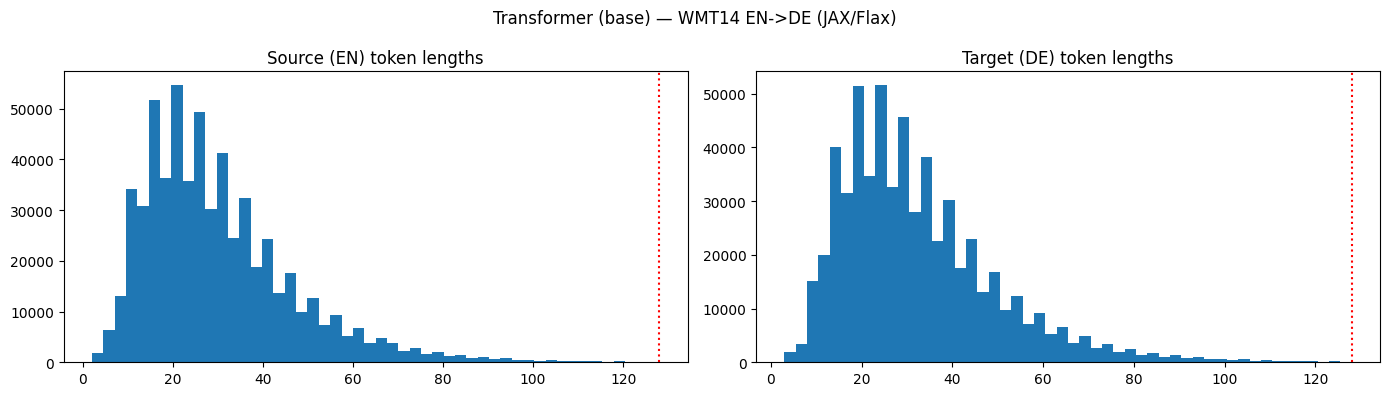

src len  mean 30.2  p95 63  max 128
tgt len  mean 32.2  p95 66  max 128


In [9]:
# A few decoded round-trips (sanity check the tokenizer)
print("Sample EN -> DE pairs (re-decoded from token ids):\n")
sf, so = tok_train["src_flat"], tok_train["src_off"]
tf_, to = tok_train["tgt_flat"], tok_train["tgt_off"]
for i in range(3):
    s = sf[so[i]:so[i+1]].tolist()
    t = tf_[to[i]:to[i+1]].tolist()
    print(f"EN: {sp.decode([x for x in s if x not in (PAD_ID, EOS_ID)])}")
    print(f"DE: {sp.decode([x for x in t if x not in (PAD_ID, BOS_ID, EOS_ID)])}")
    print(f"    src_len={len(s)}  tgt_len={len(t)}\n")

src_lens = np.diff(tok_train["src_off"])
tgt_lens = np.diff(tok_train["tgt_off"])
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(src_lens, bins=50); ax[0].set_title("Source (EN) token lengths"); ax[0].axvline(MAX_LEN, c="r", ls=":")
ax[1].hist(tgt_lens, bins=50); ax[1].set_title("Target (DE) token lengths"); ax[1].axvline(MAX_LEN, c="r", ls=":")
plt.suptitle(NOTEBOOK_TITLE); plt.tight_layout(); plt.show()
print(f"src len  mean {src_lens.mean():.1f}  p95 {np.percentile(src_lens,95):.0f}  max {src_lens.max()}")
print(f"tgt len  mean {tgt_lens.mean():.1f}  p95 {np.percentile(tgt_lens,95):.0f}  max {tgt_lens.max()}")

## 5 · Model — Transformer (Flax Linen)

Faithful "Attention Is All You Need" (base) implementation in Flax Linen.

**Interface contract**
```
model = Transformer(vocab_size=VOCAB_SIZE, pad_id=PAD_ID, **MODEL_CFG)
logits = model.apply({"params": params}, src, tgt_in,
                     train=<bool>, rngs={"dropout": rng} if train else None)
```
- `src`  : `int32 (B, S)` — source token ids (already `... + EOS`, right-padded with `pad_id`).
- `tgt_in`: `int32 (B, T)` — decoder input = target shifted right (`BOS ...`); the
  harness does the shift.
- returns `logits` : `float32 (B, T, vocab_size)` aligned to predict `tgt_out`.
- **No mutable collections** (LayerNorm only — there is no `batch_stats`).

**Architecture details:**
Token embedding scaled by √d_model · sinusoidal positional encoding · N encoder
layers (multi-head self-attention → position-wise FFN, each wrapped in residual
+ post-LayerNorm) · N decoder layers (masked self-attention → cross-attention → FFN)
· **padding mask** derived from `pad_id` (both sides) · **causal mask** in the
decoder self-attention · residual dropout on sub-layer outputs and
on the embedding+PE sum · final projection to `vocab_size` (weight-tied with the
token embedding).

`MODEL_CFG` is fixed for both presets (paper base): d_model=512, h=8, N=6,
d_ff=2048, dropout=0.1 (paper uses 0.3 only for the *big* model).

In [10]:
# ── Model config (paper "base"; identical for both presets) ──────────────
MODEL_CFG = dict(
    d_model     = 512,
    num_heads   = 8,
    num_layers  = 6,
    d_ff        = 2048,
    max_len     = MAX_LEN,
    dropout_rate= 0.1,
)
ACTIVATION = "relu"   # paper FFN is max(0, .)  -> relu. Try "gelu" as an experiment.

In [11]:
# ── §5 · Model — Transformer (Flax Linen) ────────────────────────────────
# Faithful "Attention Is All You Need" (base) implementation.
# Drop-in for the §5 cell: keeps the exact class signature & contract:
#   logits = model.apply({"params": params}, src, tgt_in,
#                        train=<bool>, rngs={"dropout": rng} if train else None)
#   src (B,S) int32, tgt_in (B,T) int32  ->  logits (B,T,vocab_size)
# LayerNorm only (no batch_stats). Post-LayerNorm, as in the original paper.

import numpy as np
import jax
import jax.numpy as jnp
import flax.linen as nn

# ── Model config (as in the notebook) ──
# MODEL_PRESET / MODEL_CFG / ACTIVATION are defined just above in the notebook.
# For standalone use, sensible defaults:
try:
    MODEL_CFG
except NameError:
    MODEL_CFG = dict(d_model=256, num_heads=4, num_layers=4, d_ff=1024,
                     max_len=128, dropout_rate=0.1)
    ACTIVATION = "relu"

_ACT = {"relu": jax.nn.relu, "gelu": jax.nn.gelu,
        "tanh": jax.nn.tanh, "sigmoid": jax.nn.sigmoid}
_NEG = -1e9   # additive-style mask fill via where(keep, score, _NEG)


def sinusoidal_positional_encoding(length: int, d_model: int) -> jnp.ndarray:
    """PE(pos,2i)=sin(pos/10000^(2i/d)), PE(pos,2i+1)=cos(...). Shape (length, d)."""
    pos = np.arange(length)[:, None]                      # (L, 1)
    idx = np.arange(d_model)[None, :]                     # (1, d)
    div = np.power(10000.0, (2 * (idx // 2)) / d_model)   # (1, d) — pairs share a rate
    angles = pos / div                                    # (L, d)
    pe = np.empty((length, d_model), np.float32)
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return jnp.asarray(pe)                                 # constant, not a param


class MultiHeadAttention(nn.Module):
    d_model: int
    num_heads: int

    @nn.compact
    def __call__(self, q_in, kv_in, mask):
        # q_in (B,Lq,d), kv_in (B,Lk,d); mask (B|1, 1, Lq|1, Lk) bool, True=keep
        assert self.d_model % self.num_heads == 0
        d_k = self.d_model // self.num_heads
        B, Lq, _ = q_in.shape
        Lk = kv_in.shape[1]

        q = nn.Dense(self.d_model, use_bias=False, name="q_proj")(q_in)
        k = nn.Dense(self.d_model, use_bias=False, name="k_proj")(kv_in)
        v = nn.Dense(self.d_model, use_bias=False, name="v_proj")(kv_in)

        def heads(x, L):                                   # (B,L,d) -> (B,h,L,d_k)
            return x.reshape(B, L, self.num_heads, d_k).transpose(0, 2, 1, 3)
        q, k, v = heads(q, Lq), heads(k, Lk), heads(v, Lk)

        scores = jnp.einsum("bhqd,bhkd->bhqk", q, k) / np.sqrt(d_k)   # (B,h,Lq,Lk)
        if mask is not None:
            scores = jnp.where(mask, scores, _NEG)
        attn = jax.nn.softmax(scores, axis=-1)
        ctx = jnp.einsum("bhqk,bhkd->bhqd", attn, v)       # (B,h,Lq,d_k)
        ctx = ctx.transpose(0, 2, 1, 3).reshape(B, Lq, self.d_model)
        return nn.Dense(self.d_model, use_bias=False, name="out_proj")(ctx)


class FeedForward(nn.Module):
    d_ff: int
    d_model: int
    activation: str = "relu"

    @nn.compact
    def __call__(self, x):
        h = _ACT[self.activation](nn.Dense(self.d_ff, name="fc1")(x))
        return nn.Dense(self.d_model, name="fc2")(h)       # (B,L,d_model)


class EncoderLayer(nn.Module):
    d_model: int
    num_heads: int
    d_ff: int
    dropout_rate: float
    activation: str

    @nn.compact
    def __call__(self, x, src_mask, train):
        drop = nn.Dropout(self.dropout_rate, deterministic=not train)
        a = MultiHeadAttention(self.d_model, self.num_heads, name="self_attn")(x, x, src_mask)
        x = nn.LayerNorm(name="ln1")(x + drop(a))          # post-LN: Norm(x + Sublayer(x))
        f = FeedForward(self.d_ff, self.d_model, self.activation, name="ffn")(x)
        x = nn.LayerNorm(name="ln2")(x + drop(f))
        return x


class DecoderLayer(nn.Module):
    d_model: int
    num_heads: int
    d_ff: int
    dropout_rate: float
    activation: str

    @nn.compact
    def __call__(self, x, enc_out, self_mask, cross_mask, train):
        drop = nn.Dropout(self.dropout_rate, deterministic=not train)
        a = MultiHeadAttention(self.d_model, self.num_heads, name="self_attn")(x, x, self_mask)
        x = nn.LayerNorm(name="ln1")(x + drop(a))
        c = MultiHeadAttention(self.d_model, self.num_heads, name="cross_attn")(x, enc_out, cross_mask)
        x = nn.LayerNorm(name="ln2")(x + drop(c))
        f = FeedForward(self.d_ff, self.d_model, self.activation, name="ffn")(x)
        x = nn.LayerNorm(name="ln3")(x + drop(f))
        return x


class Transformer(nn.Module):
    vocab_size: int
    d_model: int = 512
    num_heads: int = 8
    num_layers: int = 6
    d_ff: int = 2048
    max_len: int = 256
    dropout_rate: float = 0.1
    pad_id: int = 0
    activation: str = "relu"

    @nn.compact
    def __call__(self, src, tgt_in, train: bool = True):
        # Shared embedding (input enc, input dec, and tied output projection),
        # init at stddev d_model^-0.5 so the *sqrt(d_model) input scaling lands
        # at unit magnitude (comparable to the sinusoidal PE) while the tied
        # output logits stay well-scaled.
        embed = nn.Embed(self.vocab_size, self.d_model,
                         embedding_init=nn.initializers.normal(stddev=self.d_model ** -0.5),
                         name="shared_embed")
        pe = sinusoidal_positional_encoding(self.max_len, self.d_model)
        scale = np.sqrt(self.d_model).astype(np.float32)

        S, T = src.shape[1], tgt_in.shape[1]
        # masks, True = keep
        src_pad = (src != self.pad_id)[:, None, None, :]            # (B,1,1,S)
        tgt_pad = (tgt_in != self.pad_id)[:, None, None, :]         # (B,1,1,T)
        causal  = jnp.tril(jnp.ones((T, T), bool))[None, None]      # (1,1,T,T)
        enc_mask       = src_pad                                    # encoder self-attn
        dec_self_mask  = tgt_pad & causal                          # masked decoder self-attn
        cross_mask     = src_pad                                    # decoder->encoder (keys=S)

        # Encoder
        x = embed(src) * scale + pe[:S][None]
        x = nn.Dropout(self.dropout_rate, deterministic=not train)(x)
        for i in range(self.num_layers):
            x = EncoderLayer(self.d_model, self.num_heads, self.d_ff,
                             self.dropout_rate, self.activation, name=f"enc_{i}")(x, enc_mask, train)
        enc_out = x                                                 # no final LN (post-LN stack)

        # Decoder
        y = embed(tgt_in) * scale + pe[:T][None]
        y = nn.Dropout(self.dropout_rate, deterministic=not train)(y)
        for i in range(self.num_layers):
            y = DecoderLayer(self.d_model, self.num_heads, self.d_ff,
                             self.dropout_rate, self.activation,
                             name=f"dec_{i}")(y, enc_out, dec_self_mask, cross_mask, train)

        return embed.attend(y)                                      # tied projection -> (B,T,V)


# Construction matches the harness call (plus activation wiring from the notebook).
model = Transformer(vocab_size=VOCAB_SIZE, pad_id=PAD_ID, activation=ACTIVATION, **MODEL_CFG)
print("Model module constructed. Run §5.1 to check params & output shape.")

Model module constructed. Run §5.1 to check params & output shape.


### 5.1 · Param count / shape check

In [13]:
key, k_p, k_d = jax.random.split(key, 3)
dummy_src = jnp.ones((2, 16), jnp.int32)
dummy_tgt = jnp.ones((2, 16), jnp.int32)
variables = model.init({"params": k_p, "dropout": k_d}, dummy_src, dummy_tgt, train=False)
n_params = sum(np.prod(p.shape) for p in jax.tree_util.tree_leaves(variables["params"]))
print(f"Total trainable parameters : {n_params:,}")
logits = model.apply(variables, dummy_src, dummy_tgt, train=False)
print(f"Output shape               : {logits.shape}  (expect (2, 16, {VOCAB_SIZE}))")
assert logits.shape == (2, 16, VOCAB_SIZE), "Output shape must be (B, T, vocab_size)."
# Reference: the paper's base model is ~65M params on a 37k shared vocab.

Total trainable parameters : 60,485,632
Output shape               : (2, 16, 32000)  (expect (2, 16, 32000))


## 6 · Training state, loss & metrics

Plain `TrainState` (no `batch_stats`). Optimiser = **Adam (β1=0.9, β2=0.98,
ε=1e-9)** with the paper's **Noam** schedule
`lr = d_model^-0.5 · min(step^-0.5, step · warmup^-1.5)`, warmup = 4000.
Loss = **label-smoothed** cross-entropy (ε=0.1), masked over `pad_id`.

In [15]:
# ── Config (tune these) ──────────────────────────────────────────────────
WARMUP_STEPS     = 4000
LABEL_SMOOTHING  = 0.1
D_MODEL          = MODEL_CFG["d_model"]
if PRESET == "paper":
    TRAIN_STEPS  = 100_000
else:
    TRAIN_STEPS  = 15_000      # stop earlier anytime; best ckpt is kept
EVAL_EVERY       = 1000
CKPT_EVERY       = 2000
LOG_EVERY        = 100
# CLIP_NORM = 1.0   # paper does not clip; uncomment to add optax.clip_by_global_norm

def noam_schedule(step):
    s = jnp.asarray(step, jnp.float32) + 1.0
    return (D_MODEL ** -0.5) * jnp.minimum(s ** -0.5, s * (WARMUP_STEPS ** -1.5))

optimizer = optax.adam(learning_rate=noam_schedule, b1=0.9, b2=0.98, eps=1e-9)
# optimizer = optax.chain(optax.clip_by_global_norm(CLIP_NORM), optimizer)

class TrainState(train_state.TrainState):
    pass   # LayerNorm only -> nothing extra to carry

def label_smoothed_loss(logits, targets):
    # logits (B,T,V), targets (B,T). Mask out pad positions.
    vocab = logits.shape[-1]
    conf  = 1.0 - LABEL_SMOOTHING
    low   = LABEL_SMOOTHING / (vocab - 1)
    onehot = jax.nn.one_hot(targets, vocab)
    soft   = onehot * conf + (1.0 - onehot) * low
    logp   = jax.nn.log_softmax(logits, axis=-1)
    per_tok = -jnp.sum(soft * logp, axis=-1)          # (B,T)
    mask = (targets != PAD_ID).astype(jnp.float32)
    return jnp.sum(per_tok * mask) / jnp.maximum(jnp.sum(mask), 1.0)

def token_metrics(logits, targets, loss):
    mask = (targets != PAD_ID).astype(jnp.float32)
    correct = (jnp.argmax(logits, -1) == targets).astype(jnp.float32) * mask
    acc = jnp.sum(correct) / jnp.maximum(jnp.sum(mask), 1.0)
    # unsmoothed CE for an honest perplexity
    logp = jax.nn.log_softmax(logits, -1)
    ce_tok = -jnp.take_along_axis(logp, targets[..., None], axis=-1)[..., 0]
    ce = jnp.sum(ce_tok * mask) / jnp.maximum(jnp.sum(mask), 1.0)
    return {"loss": loss, "acc": acc, "ce": ce}

key, init_key, drop_key = jax.random.split(key, 3)
init_vars = model.init({"params": init_key, "dropout": drop_key},
                       dummy_src, dummy_tgt, train=False)
state = TrainState.create(apply_fn=model.apply, params=init_vars["params"], tx=optimizer)
print("TrainState ready. Optimiser: Adam(0.9, 0.98, 1e-9) + Noam warmup", WARMUP_STEPS)

TrainState ready. Optimiser: Adam(0.9, 0.98, 1e-9) + Noam warmup 4000


## 7 · Checkpoint helpers (safetensors)

Params only (no optimiser state, no `batch_stats`). We also **keep the last
`KEEP_LAST_N` periodic checkpoints** so §12 can reproduce the paper's
checkpoint-averaging trick.

In [16]:
from safetensors.numpy import save_file as st_save, load_file as st_load

KEEP_LAST_N = 5   # paper averages the last 5 (base) / 20 (big) checkpoints

_RUN_SLUG = (
    f"transformer-base"
    f"_{DATASET_SLUG}"
    f"_ln"
    f"_dropout{MODEL_CFG['dropout_rate']}"
    f"_{ACTIVATION}"
    f"_adam"
    f"_dmodel{MODEL_CFG['d_model']}"
)
RUN_TS  = datetime.datetime.now().strftime("%Y-%m-%d_%H%M%S")
RUN_DIR = os.path.join(DRIVE_CHECKPOINTS_ROOT, _RUN_SLUG, RUN_TS)
os.makedirs(RUN_DIR, exist_ok=True)
print("Run dir:", RUN_DIR)

def _flatten_params(pytree, prefix=""):
    out = {}
    for k, v in pytree.items():
        full = f"{prefix}/{k}" if prefix else k
        if isinstance(v, dict):
            out.update(_flatten_params(v, prefix=full))
        else:
            out[full] = np.asarray(v)
    return out

def _unflatten_params(flat):
    root = {}
    for k, v in flat.items():
        d = root
        parts = k.split("/")
        for p in parts[:-1]:
            d = d.setdefault(p, {})
        d[parts[-1]] = jnp.asarray(v)
    return root

def _meta(step, score, label):
    return {
        "architecture": "transformer-base", "dataset": DATASET_SLUG,
        "vocab_size": int(VOCAB_SIZE), "max_len": int(MAX_LEN), "norm": "ln",
        "activation": ACTIVATION, "dropout_rate": MODEL_CFG["dropout_rate"],
        "optimiser": "adam", "base_lr_schedule": "noam", "warmup_steps": int(WARMUP_STEPS),
        "label_smoothing": LABEL_SMOOTHING, "d_model": MODEL_CFG["d_model"],
        "num_heads": MODEL_CFG["num_heads"], "num_layers": MODEL_CFG["num_layers"],
        "d_ff": MODEL_CFG["d_ff"], "step": int(step), "dev_score": float(score),
        "score_metric": "val_perplexity", "label": label,
        "run_slug": _RUN_SLUG, "run_timestamp": RUN_TS,
    }

def save_checkpoint(state, step, score, label="checkpoint"):
    flat = {f"params/{k}": v for k, v in _flatten_params(state.params).items()}
    fname = os.path.join(RUN_DIR, f"{label}_step{step:06d}_ppl{score:06.2f}.safetensors")
    st_save(flat, fname)
    with open(fname.replace(".safetensors", "_meta.json"), "w") as f:
        json.dump(_meta(step, score, label), f, indent=2)
    # prune old periodic checkpoints, keep the most recent KEEP_LAST_N
    if label == "checkpoint":
        ck = sorted(glob.glob(os.path.join(RUN_DIR, "checkpoint_step*.safetensors")))
        for old in ck[:-KEEP_LAST_N]:
            os.remove(old);
            mj = old.replace(".safetensors", "_meta.json")
            if os.path.isfile(mj): os.remove(mj)
    return fname

def save_best_checkpoint(state, step, score):
    for old in glob.glob(os.path.join(RUN_DIR, "best_*")):
        os.remove(old)
    return save_checkpoint(state, step, score, label="best")

def load_params(safetensors_path):
    flat = st_load(safetensors_path)
    stripped = {k[len("params/"):]: v for k, v in flat.items() if k.startswith("params/")}
    return _unflatten_params(stripped)

print("Checkpoint helpers ready.")

Run dir: /content/drive/MyDrive/colab_checkpoints/transformer-base_wmt14_ende_ln_dropout0.1_relu_adam_dmodel512/2026-05-31_115718
Checkpoint helpers ready.


## 8 · JIT-compiled train / eval steps

In [17]:
@jax.jit
def compute_grads(params, src, tgt_in, tgt_out, dropout_rng):
    def loss_fn(p):
        logits = model.apply({"params": p}, src, tgt_in,
                             train=True, rngs={"dropout": dropout_rng})
        return label_smoothed_loss(logits, tgt_out), logits
    (loss, logits), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    n_tok = jnp.sum((tgt_out != PAD_ID).astype(jnp.float32))
    return grads, token_metrics(logits, tgt_out, loss), n_tok

@jax.jit
def apply_grads(state, grads):
    return state.apply_gradients(grads=grads)

@jax.jit
def eval_step(params, src, tgt_in, tgt_out):
    logits = model.apply({"params": params}, src, tgt_in, train=False)
    loss = label_smoothed_loss(logits, tgt_out)
    return token_metrics(logits, tgt_out, loss)

def split_tgt(tgt):
    # decoder input = target[:-1] (BOS ...), labels = target[1:] (... EOS)
    return tgt[:, :-1], tgt[:, 1:]

print("Train/eval steps compiled lazily on first call.")

Train/eval steps compiled lazily on first call.


## 9 · Training loop (step-based, with gradient accumulation)

Each optimiser step accumulates grads over `ACCUM_STEPS` bucketed micro-batches
(≈25k tokens total, matching the paper). Eval/checkpoint cadence is in steps.

In [18]:
def evaluate(params, ds, max_batches=None):
    tot = {"loss": 0.0, "acc": 0.0, "ce": 0.0}; n = 0
    for i, (src, tgt) in enumerate(tfds.as_numpy(ds)):
        if max_batches is not None and i >= max_batches: break
        ti, to = split_tgt(tgt)
        m = eval_step(params, src, ti, to)
        for k in tot: tot[k] += float(m[k])
        n += 1
    if n == 0: return {"loss": float("nan"), "acc": 0.0, "ppl": float("nan")}
    return {"loss": tot["loss"]/n, "acc": tot["acc"]/n, "ppl": math.exp(tot["ce"]/n)}

history = {"step": [], "train_loss": [], "train_ppl": [],
           "val_loss": [], "val_ppl": [], "lr": []}
best_val_ppl = float("inf"); best_step = 0
total_t0 = time.perf_counter()

hdr = f"{'Step':>7}  {'Time(s)':>8}  {'LR':>9}  {'Tr Loss':>9}  {'Tr PPL':>9}  {'Val Loss':>9}  {'Val PPL':>9}  {'Saved':>9}"
print(hdr); print("-" * len(hdr))

key, loop_key = jax.random.split(key)
t0 = time.perf_counter()
run_loss = run_ce = run_tok = 0.0

for step in range(1, TRAIN_STEPS + 1):
    grad_accum = None; step_tok = 0.0
    for _ in range(ACCUM_STEPS):
        src, tgt = next(train_iter)
        ti, to = split_tgt(tgt)
        loop_key, dk = jax.random.split(loop_key)
        grads, m, n_tok = compute_grads(state.params, src, ti, to, dk)
        # token-weighted accumulation
        grad_accum = grads if grad_accum is None else \
            jax.tree_util.tree_map(lambda a, b: a + b, grad_accum, grads)
        run_loss += float(m["loss"]); run_ce += float(m["ce"]); step_tok += float(n_tok)
    grad_accum = jax.tree_util.tree_map(lambda g: g / ACCUM_STEPS, grad_accum)
    state = apply_grads(state, grad_accum)

    if step % LOG_EVERY == 0:
        tr_loss = run_loss / (LOG_EVERY * ACCUM_STEPS)
        tr_ppl  = math.exp(run_ce / (LOG_EVERY * ACCUM_STEPS))
        run_loss = run_ce = 0.0
        lr = float(noam_schedule(state.step))
        do_eval = (step % EVAL_EVERY == 0)
        val = evaluate(state.params, val_ds, max_batches=50) if do_eval else \
              {"loss": float("nan"), "ppl": float("nan")}

        saved = ""
        if step % CKPT_EVERY == 0:
            save_checkpoint(state, step, val["ppl"] if do_eval else tr_ppl); saved = "ckpt"
        if do_eval and val["ppl"] < best_val_ppl:
            best_val_ppl, best_step = val["ppl"], step
            save_best_checkpoint(state, step, val["ppl"])
            saved = "BEST" if saved == "" else "ckpt+BEST"

        history["step"].append(step); history["lr"].append(lr)
        history["train_loss"].append(tr_loss); history["train_ppl"].append(tr_ppl)
        history["val_loss"].append(val["loss"]); history["val_ppl"].append(val["ppl"])
        dt = time.perf_counter() - t0; t0 = time.perf_counter()
        print(f"{step:>7}  {dt:>8.1f}  {lr:>9.2e}  {tr_loss:>9.4f}  {tr_ppl:>9.2f}  "
              f"{val['loss']:>9.4f}  {val['ppl']:>9.2f}  {saved:>9}")

total_time = time.perf_counter() - total_t0
print(f"\nBest val perplexity : {best_val_ppl:.2f}  (step {best_step})")
print(f"Total training time : {total_time/60:.1f} min")
print(f"\nCheckpoints saved to:\n  {RUN_DIR}")

   Step   Time(s)         LR    Tr Loss     Tr PPL   Val Loss    Val PPL      Saved
-----------------------------------------------------------------------------------
    100     488.5   1.76e-05     9.7593   15260.96        nan        nan           
    200      36.1   3.51e-05     8.7368    4889.25        nan        nan           
    300      35.7   5.26e-05     8.0712    2261.79        nan        nan           
    400      35.8   7.01e-05     7.8100    1635.88        nan        nan           
    500      35.8   8.75e-05     7.6272    1319.86        nan        nan           
    600      35.8   1.05e-04     7.4035    1018.11        nan        nan           
    700      36.4   1.22e-04     7.2073     809.01        nan        nan           
    800      35.7   1.40e-04     7.0255     653.72        nan        nan           
    900      35.1   1.57e-04     6.8696     545.01        nan        nan           
   1000     187.4   1.75e-04     6.7476     472.32     6.7681     476.15    

## 10 · Training curves

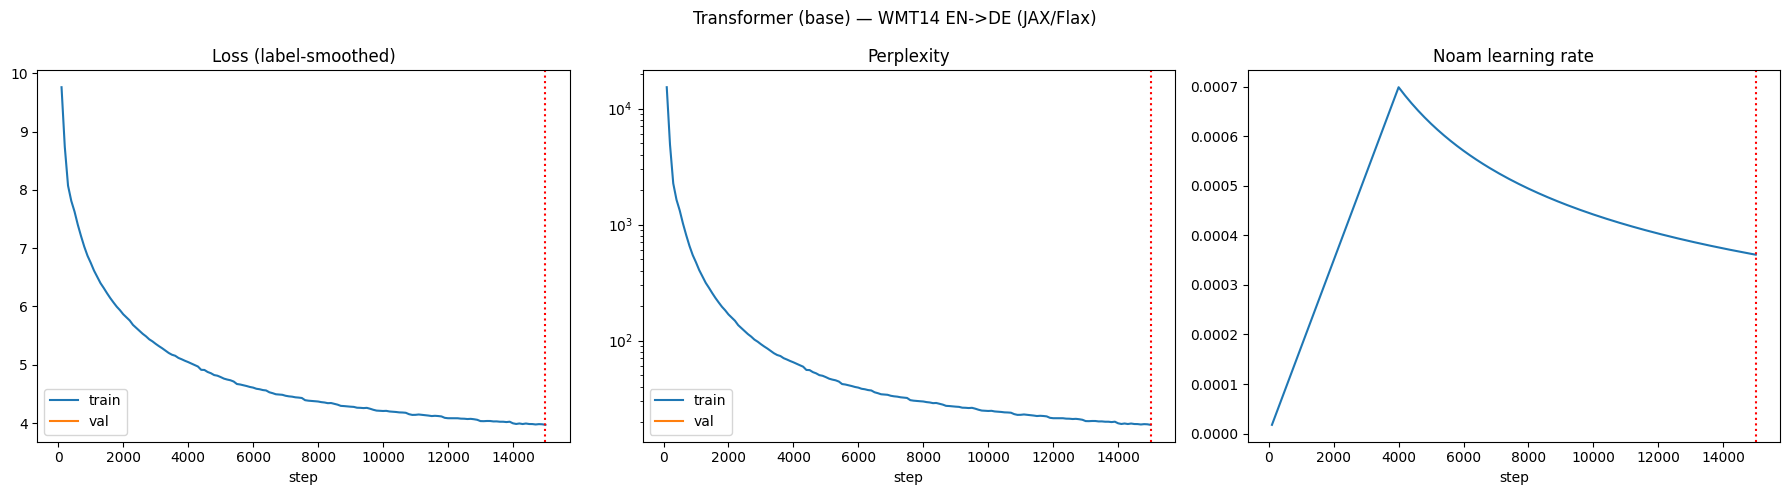

In [19]:
steps = history["step"]
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].plot(steps, history["train_loss"], label="train")
ax[0].plot(steps, history["val_loss"], label="val")
ax[0].set_title("Loss (label-smoothed)"); ax[0].set_xlabel("step"); ax[0].legend()
ax[1].plot(steps, history["train_ppl"], label="train")
ax[1].plot(steps, history["val_ppl"], label="val")
ax[1].set_title("Perplexity"); ax[1].set_xlabel("step"); ax[1].set_yscale("log"); ax[1].legend()
ax[2].plot(steps, history["lr"]); ax[2].set_title("Noam learning rate"); ax[2].set_xlabel("step")
for a in ax:
    if best_step: a.axvline(best_step, c="r", ls=":")
plt.suptitle(NOTEBOOK_TITLE); plt.tight_layout(); plt.show()

## 11 · Inference — decoding & BLEU

The model exposes a single `__call__`, so we decode by re-running the full
forward at each step (no KV-cache). That's fine for an eval subset; for speed at
scale you'd add an incremental `encode` / `decode_step` cache to the model.

- **Greedy** (default, fast) and **beam search** (beam=4, length penalty α=0.6,
  `max_len = src_len + 50`), matching the paper's decode settings.
- BLEU via `sacrebleu` on a configurable slice of `newstest2014`.

In [20]:
# ── Config ──
DECODE       = "greedy"   # "greedy" | "beam"
BEAM_SIZE    = 4
LENGTH_ALPHA = 0.6
MAX_EXTRA    = 50
EVAL_PAIRS   = 200        # newstest2014 sentences to score (3003 total; raise for full)

def strip_special(ids):
    return [int(x) for x in ids if int(x) not in (PAD_ID, BOS_ID, EOS_ID)]

@partial(jax.jit, static_argnames=())
def _next_logits(params, src, tgt):
    return model.apply({"params": params}, src, tgt, train=False)[:, -1, :]

def greedy_decode(params, src_batch, max_len):
    B = src_batch.shape[0]
    tgt = jnp.full((B, 1), BOS_ID, jnp.int32)
    finished = jnp.zeros((B,), bool)
    for _ in range(max_len):
        nxt = jnp.argmax(_next_logits(params, src_batch, tgt), -1).astype(jnp.int32)
        nxt = jnp.where(finished, PAD_ID, nxt)
        tgt = jnp.concatenate([tgt, nxt[:, None]], axis=1)
        finished = finished | (nxt == EOS_ID)
        if bool(jnp.all(finished)): break
    return np.asarray(tgt)

def beam_decode_one(params, src_ids, beam, alpha, max_extra):
    src_len = int(np.sum(src_ids != PAD_ID))
    max_len = src_len + max_extra
    src_b = jnp.asarray(src_ids[None, :])
    beams = [([BOS_ID], 0.0)]; completed = []
    for _ in range(max_len):
        seqs = jnp.asarray([b[0] for b in beams], jnp.int32)
        src_rep = jnp.repeat(src_b, seqs.shape[0], axis=0)
        logp = np.asarray(jax.nn.log_softmax(
            model.apply({"params": params}, src_rep, seqs, train=False)[:, -1, :], -1))
        cands = []
        for i, (seq, score) in enumerate(beams):
            top = np.argpartition(-logp[i], beam)[:beam]
            for tok in top:
                cands.append((seq + [int(tok)], score + float(logp[i, tok])))
        cands.sort(key=lambda x: x[1], reverse=True)
        beams = []
        for seq, score in cands:
            if seq[-1] == EOS_ID:
                lp = ((5 + len(seq)) / 6) ** alpha
                completed.append((seq, score / lp))
            else:
                beams.append((seq, score))
            if len(beams) >= beam: break
        if not beams: break
    if not completed:
        seq, score = max(beams, key=lambda x: x[1])
        lp = ((5 + len(seq)) / 6) ** alpha
        completed.append((seq, score / lp))
    return max(completed, key=lambda x: x[1])[0]

# Build a flat list of (src_ids, ref_text) from the test split
sf, so = tok_test["src_flat"], tok_test["src_off"]
tf_, to = tok_test["tgt_flat"], tok_test["tgt_off"]
n_test = min(EVAL_PAIRS, len(so) - 1)
hyps, refs, srcs = [], [], []
t0 = time.perf_counter()
for i in range(n_test):
    src_ids = sf[so[i]:so[i+1]]
    ref_ids = tf_[to[i]:to[i+1]]
    if DECODE == "beam":
        out = beam_decode_one(state.params, src_ids, BEAM_SIZE, LENGTH_ALPHA, MAX_EXTRA)
    else:
        padded = np.full((1, MAX_LEN), PAD_ID, np.int32); padded[0, :len(src_ids)] = src_ids
        out = greedy_decode(state.params, jnp.asarray(padded), len(src_ids) + MAX_EXTRA)[0]
    hyps.append(sp.decode(strip_special(out)))
    refs.append(sp.decode(strip_special(ref_ids)))
    srcs.append(sp.decode(strip_special(src_ids)))
print(f"Decoded {n_test} sentences ({DECODE}) in {time.perf_counter()-t0:.1f}s")
bleu = sacrebleu.corpus_bleu(hyps, [refs])
print(f"\nBLEU on {n_test} newstest2014 pairs : {bleu.score:.2f}")
print("(Paper base = 27.3 on the FULL set after 100k steps; expect lower on a subset/short run.)")

Decoded 200 sentences (greedy) in 673.2s

BLEU on 200 newstest2014 pairs : 1.62
(Paper base = 27.3 on the FULL set after 100k steps; expect lower on a subset/short run.)


## 12 · Sample translations & checkpoint averaging

In [21]:
print("Sample translations (source / reference / hypothesis):\n")
for i in range(min(6, len(hyps))):
    print(f"SRC : {srcs[i]}")
    print(f"REF : {refs[i]}")
    print(f"HYP : {hyps[i]}\n")

# ── Checkpoint averaging (paper: average last N checkpoints) ──
def average_checkpoints(paths):
    assert paths, "no checkpoints to average"
    acc = None
    for p in paths:
        flat = {k: v for k, v in st_load(p).items() if k.startswith("params/")}
        acc = {k: v.astype(np.float64) for k, v in flat.items()} if acc is None \
              else {k: acc[k] + flat[k].astype(np.float64) for k in acc}
    avg = {k: (v / len(paths)).astype(np.float32) for k, v in acc.items()}
    stripped = {k[len("params/"):]: v for k, v in avg.items()}
    return _unflatten_params(stripped)

ckpts = sorted(glob.glob(os.path.join(RUN_DIR, "checkpoint_step*.safetensors")))
if len(ckpts) >= 2:
    avg_params = average_checkpoints(ckpts[-KEEP_LAST_N:])
    val_avg = evaluate(avg_params, val_ds, max_batches=50)
    print(f"Averaged last {min(KEEP_LAST_N, len(ckpts))} checkpoints -> "
          f"val ppl {val_avg['ppl']:.2f} (single-best was {best_val_ppl:.2f})")
    # Save the averaged model for downstream use
    flat = {f"params/{k}": np.asarray(v) for k, v in _flatten_params(avg_params).items()}
    st_save(flat, os.path.join(RUN_DIR, "averaged.safetensors"))
    print("Saved averaged.safetensors")
else:
    print(f"Need >=2 periodic checkpoints to average; have {len(ckpts)}. Train longer.")

Sample translations (source / reference / hypothesis):

SRC : The school yard renovation was originally planned back in 2008/2009, however, high unplanned expenses meant that the work had to be pushed back.
REF : Ursprünglich war die Schulhofsanierung sogar schon in den Jahren 2008/2009 geplant, doch hohe unplanmäßige Ausgaben brachten eine Verschiebung.
HYP : Die nächste Hälfte der Schulausbildung wurde jedoch im Jahre 2003 wieder aufgenommen.

SRC : Consequently, they will be particularly motivated playing against their former coach.
REF : Von daher werden sie gegen ihren Ex-Coach sicher ganz besonders motiviert sein.
HYP : Sie werden deshalb besonders für ihre ehemaligen Pioniere belohnt.

SRC : They're not all experienced racers, but people looking for excitement and adventure, and an achievable path towards world-class events.
REF : Sie sind nicht alle erfahrene Rennfahrer, sondern Leute, die auf der Suche nach Spannung und Abenteuer sind sowie nach einem erreichbaren Weg zu Weltk

## Notes & further reading

**Paper setup reproduced here**
- WMT14 EN→DE, shared BPE (~37k), token-bucketed batches ≈25k tokens, dev=newstest2013, test=newstest2014.
- Base arch: d_model=512, h=8, N=6, d_ff=2048, P_drop=0.1; Adam(0.9,0.98,1e-9) + Noam warmup=4000; label smoothing ε=0.1; 100k steps.
- Decode: beam=4, α=0.6, max_len=src+50; checkpoint averaging (last 5 base / 20 big).

**Model (§5).** Embedding ×√d_model, sinusoidal PE, residual+post-LayerNorm sub-layers,
padding mask from `pad_id`, causal mask in decoder self-attention, tied
output projection. Follows the `__call__(src, tgt_in, train) -> (B,T,V)` contract.

**Knobs to experiment with**: `MODEL_CFG['dropout_rate']` (0.0/0.1/0.3),
`ACTIVATION` (relu/gelu), `WARMUP_STEPS`, `LABEL_SMOOTHING`, `TOKENS_PER_BATCH`×`ACCUM_STEPS`,
`PRESET`. For the **big** model: d_model=1024, h=16, d_ff=4096, P_drop=0.3.

**Going faster.** Decoding re-runs the full forward each step. To match production
speed, add an incremental `encode()` + cached `decode_step()`
(KV-cache); the BLEU harness can then call those instead of `__call__`.

**Feasibility.** The full base run won't finish in one Colab Pro session on one
GPU — `colab` preset + Drive checkpointing lets you resume; load with
`load_params(path)` and rebuild `state` via `TrainState.create`.